In [3]:
import polars as pl
from pathlib import Path

In [4]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_ROOT = PROJECT_ROOT / "tennis_data"
data_path = DATA_ROOT / "Data"

In [5]:
# Load home and away player data

home_team = pl.read_parquet(data_path / "home_team.parquet")
away_team = pl.read_parquet(data_path / "away_team.parquet")

print("Home team shape:", home_team.shape)
print("Away team shape:", away_team.shape)

print("\nHome team columns:")
print(home_team.columns)

print("\nAway team columns:")
print(away_team.columns)

Home team shape: (25610, 19)
Away team shape: (24203, 19)

Home team columns:
['match_id', 'name', 'slug', 'gender', 'user_count', 'residence', 'birthplace', 'height', 'weight', 'plays', 'turned_pro', 'current_prize', 'total_prize', 'player_id', 'current_rank', 'name_code', 'country', 'full_name', 'snapshot_date']

Away team columns:
['match_id', 'name', 'slug', 'gender', 'user_count', 'residence', 'birthplace', 'height', 'weight', 'plays', 'turned_pro', 'current_prize', 'total_prize', 'player_id', 'current_rank', 'name_code', 'country', 'full_name', 'snapshot_date']


In [6]:
# Inspect player_id and country columns

print("Home team:")
print(
    home_team.select(
        ["player_id", "country"]
    ).head(10)
)

print("\nAway team:")
print(
    away_team.select(
        ["player_id", "country"]
    ).head(10)
)

Home team:
shape: (10, 2)
┌───────────┬────────────┐
│ player_id ┆ country    │
│ ---       ┆ ---        │
│ i64       ┆ str        │
╞═══════════╪════════════╡
│ 287803    ┆ France     │
│ 287803    ┆ France     │
│ 62790     ┆ France     │
│ 62790     ┆ France     │
│ 64580     ┆ Croatia    │
│ 64580     ┆ Croatia    │
│ 131442    ┆ USA        │
│ 22218     ┆ France     │
│ 117916    ┆ Canada     │
│ 264344    ┆ Kazakhstan │
└───────────┴────────────┘

Away team:
shape: (10, 2)
┌───────────┬────────────┐
│ player_id ┆ country    │
│ ---       ┆ ---        │
│ i64       ┆ str        │
╞═══════════╪════════════╡
│ 192013    ┆ Canada     │
│ 192013    ┆ Canada     │
│ 273680    ┆ Italy      │
│ 273680    ┆ Italy      │
│ 77223     ┆ Spain      │
│ 77223     ┆ Spain      │
│ 88992     ┆ France     │
│ 248846    ┆ France     │
│ 163480    ┆ Kazakhstan │
│ 67154     ┆ France     │
└───────────┴────────────┘


In [7]:
# Combine home and away players

players = pl.concat([
    home_team.select(["player_id", "country"]),
    away_team.select(["player_id", "country"])
])

print("Total player records:", players.height)
print("Unique players:", players["player_id"].n_unique())

players.head(10)

Total player records: 49813
Unique players: 2644


player_id,country
i64,str
287803,"""France"""
287803,"""France"""
62790,"""France"""
62790,"""France"""
64580,"""Croatia"""
64580,"""Croatia"""
131442,"""USA"""
22218,"""France"""
117916,"""Canada"""


In [8]:
# Keep only unique players

unique_players = (
    players
    .filter(
        pl.col("player_id").is_not_null() &
        pl.col("country").is_not_null()
    )
    .unique(subset=["player_id"])
)

print("Unique players with country:", unique_players.height)

unique_players.head(10)

Unique players with country: 2644


player_id,country
i64,str
164010,"""Estonia"""
175160,"""Italy"""
190877,"""Italy"""
121122,"""Sweden"""
210012,"""Czech Republic"""
342909,"""Russia"""
45139,"""Greece"""
367820,"""France"""
369288,"""Italy"""


In [9]:
# Count unique players by country

players_by_country = (
    unique_players
    .group_by("country")
    .agg(
        pl.len().alias("number_of_players")
    )
    .sort("number_of_players", descending=True)
)

players_by_country.head(10)

country,number_of_players
str,u32
"""USA""",225
"""Italy""",205
"""France""",202
"""Russia""",137
"""Japan""",124
"""Germany""",121
"""Spain""",98
"""Argentina""",98
"""Australia""",92


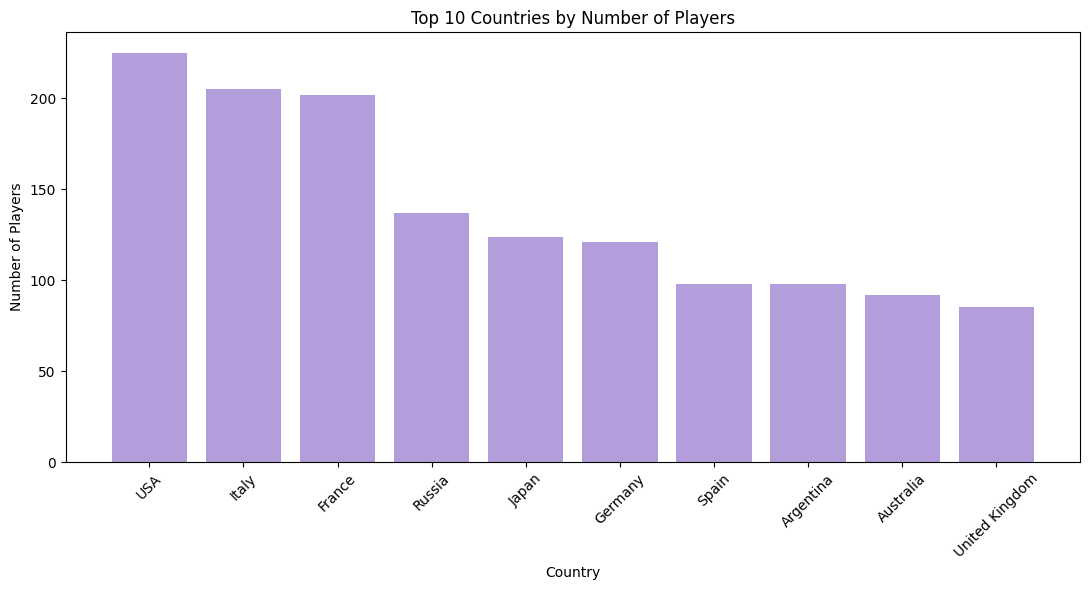

In [10]:
# Visualize top 10 countries by number of players

import matplotlib.pyplot as plt

top_10 = players_by_country.head(10)

countries = top_10["country"].to_list()
player_counts = top_10["number_of_players"].to_list()

plt.figure(figsize=(11, 6))

plt.bar(countries, player_counts, color="#B39DDB")

plt.title("Top 10 Countries by Number of Players")
plt.xlabel("Country")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()